
# TV80 Trawl Sensor Analysis

Parses a Simrad **TV80** gear-monitoring NMEA log (`$GPRMC`, `$SDDPT`, `$PSIMTV80`
sentences) and extracts:

1. **Trawl duration** — detected automatically as the longest period of steady
   vessel speed *and* steady course (i.e. the boat is towing in a straight
   line, not shooting or hauling the gear).
2. **Vessel speed** at a chosen time of interest.
3. **Net width** (door/wing spread) and **net height** (headline height),
   inferred from the `$PSIMTV80` gear-sensor channels.



## 1. Setup & configuration

In [39]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ---- EDIT THESE TWO LINES FOR YOUR OWN DATA -----------------------------
FILE_PATH = "Havfisken-D20260609-T084257.txt"    # path to the TV80 NMEA log
#FILE_PATH = "Havfisken-D20260611-T074259.txt"
QUERY_TIME = "09:23:00"
#QUERY_TIME = "08:14:00"                          # HH:MM:SS - time you care about
# ---------------------------------------------------------------------------

# Tow-detection thresholds (tune if your gear/vessel behaves differently)
ROLL_WINDOW_S   = 61    # rolling window (seconds, odd number) used to judge "steady"
SPEED_STD_MAX   = 0.25  # knots  - speed must vary less than this to count as "steady"
COURSE_STD_MAX  = 6.0   # degrees - course must vary less than this to count as "steady"
MIN_TOW_SPEED   = 1.5   # knots  - ignore very slow periods (shooting / hauling gear)

# Channel-identification thresholds
STABLE_REL_STD  = 0.10  # max (std / mean) for a PSIMTV80 channel to be "stable"
MIN_SIGNAL_M    = 0.5   # ignore near-zero / noisy channels (metres)


## 2. Parse the NMEA log

We pull out the three sentence types we need:

- `$GPRMC` → timestamp, speed over ground (SOG, knots), course over ground (COG, deg)
- `$SDDPT` → water depth under the vessel (m)
- `$PSIMTV80` → Simrad's proprietary gear-sensor datagram: timestamp, sensor channel ID, status flags, and the sensor reading itself

In [40]:

def parse_time(date_str, time_str, date_fmt="DDMMYY"):
    '''NMEA dates come in two different field orders in this log:
    $GPRMC uses DDMMYY, $PSIMTV80 uses YYMMDD. time_str is HHMMSS(.ss).'''
    hh, mm, ss = int(time_str[0:2]), int(time_str[2:4]), float(time_str[4:])
    if date_fmt == "DDMMYY":
        dd, mo, yy = int(date_str[0:2]), int(date_str[2:4]), int(date_str[4:6])
    else:  # YYMMDD
        yy, mo, dd = int(date_str[0:2]), int(date_str[2:4]), int(date_str[4:6])
    base = datetime(2000 + yy, mo, dd)
    return base + timedelta(hours=hh, minutes=mm, seconds=ss)


gprmc_rows, dpt_rows, tv80_rows = [], [], []
last_gprmc_time = None

with open(FILE_PATH, "r", errors="ignore") as f:
    for line in f:
        line = line.strip()

        if line.startswith("$GPRMC"):
            p = line.split(",")
            try:
                t = parse_time(p[9], p[1], date_fmt="DDMMYY")
                gprmc_rows.append({"time": t, "sog_kn": float(p[7]), "cog_deg": float(p[8])})
                last_gprmc_time = t
            except (IndexError, ValueError):
                continue

        elif line.startswith("$SDDPT") and last_gprmc_time is not None:
            p = line.split(",")
            try:
                dpt_rows.append({"time": last_gprmc_time, "depth_m": float(p[1])})
            except (IndexError, ValueError):
                continue

        elif line.startswith("$PSIMTV80"):
            p = line.split(",")
            try:
                t = parse_time(p[2], p[1], date_fmt="YYMMDD")
                tv80_rows.append({
                    "time": t,
                    "sensor_id": p[15],
                    "status1": p[16],
                    "status2": p[17],
                    "value": float(p[18]),
                    "speed" : float(p[11]),
                    "gear_depth_m": float(p[14]) if p[14] else np.nan,
                })
            except (IndexError, ValueError):
                continue

gprmc = pd.DataFrame(gprmc_rows).sort_values("time").reset_index(drop=True)
dpt   = pd.DataFrame(dpt_rows).sort_values("time").reset_index(drop=True)
tv80  = pd.DataFrame(tv80_rows).sort_values("time").reset_index(drop=True)

print(f"Parsed {len(gprmc):,} $GPRMC, {len(dpt):,} $SDDPT, {len(tv80):,} $PSIMTV80 records")
gprmc.head()


Parsed 3,600 $GPRMC, 3,596 $SDDPT, 1,757 $PSIMTV80 records


,time,sog_kn,cog_deg
0,2026-06-09 08:43:04.320,2.1,353.7
1,2026-06-09 08:43:05.320,2.1,354.3
2,2026-06-09 08:43:06.320,2.1,353.2
3,2026-06-09 08:43:07.320,2.0,353.3
4,2026-06-09 08:43:08.120,2.0,353.1


In [41]:
with open(FILE_PATH, "r", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if line.startswith("$PSIMTV80"):
            x = line.split(",")
print(x)
print(x[18])

['$PSIMTV80', '094248', '260609', '5548.4328000', 'N', '01243.4165000', 'E', '', '', '', '', '01.30', '181.80', '188.40', '0017.3', '07', 'a7', '', '-0086.70', '10', '1018700*6A']
-0086.70


## 3. Detect the trawl (steady-tow) window

A vessel that is actually towing the net holds a roughly constant speed and a roughly constant course. Shooting and hauling the gear, by contrast, show low/changing speed and an erratic course (the boat is turning or running gear out/in). We find the **longest** stretch where both speed and course are stable — that's the trawl.

In [42]:

# resample to a clean 1-second grid so the rolling window is well-defined
g = gprmc.set_index("time").resample("1s").mean().interpolate().reset_index()

roll_speed_std  = g["sog_kn"].rolling(ROLL_WINDOW_S, center=True).std()
roll_course_std = g["cog_deg"].rolling(ROLL_WINDOW_S, center=True).std()
roll_speed_mean = g["sog_kn"].rolling(ROLL_WINDOW_S, center=True).mean()

steady = (
    (roll_speed_std < SPEED_STD_MAX) &
    (roll_course_std < COURSE_STD_MAX) &
    (roll_speed_mean > MIN_TOW_SPEED)
).fillna(False)

# longest contiguous run of `steady == True`
steady_int = steady.astype(int).to_numpy()
changes = np.diff(np.concatenate(([0], steady_int, [0])))
starts = np.where(changes == 1)[0]
ends   = np.where(changes == -1)[0]
best   = np.argmax(ends - starts)

tow_start = g["time"].iloc[starts[best]]
tow_end   = g["time"].iloc[ends[best] - 1]
tow_duration = tow_end - tow_start

print("Trawl (steady tow) window")
print("--------------------------")
print(f"Start    : {tow_start}")
print(f"End      : {tow_end}")
print(f"Duration : {tow_duration}  ({tow_duration.total_seconds()/60:.1f} minutes)")


Trawl (steady tow) window
--------------------------
Start    : 2026-06-09 09:22:33
End      : 2026-06-09 09:35:04
Duration : 0 days 00:12:31  (12.5 minutes)


### Visual check
Plot speed and course over time with the detected tow window shaded, to sanity-check the detection.

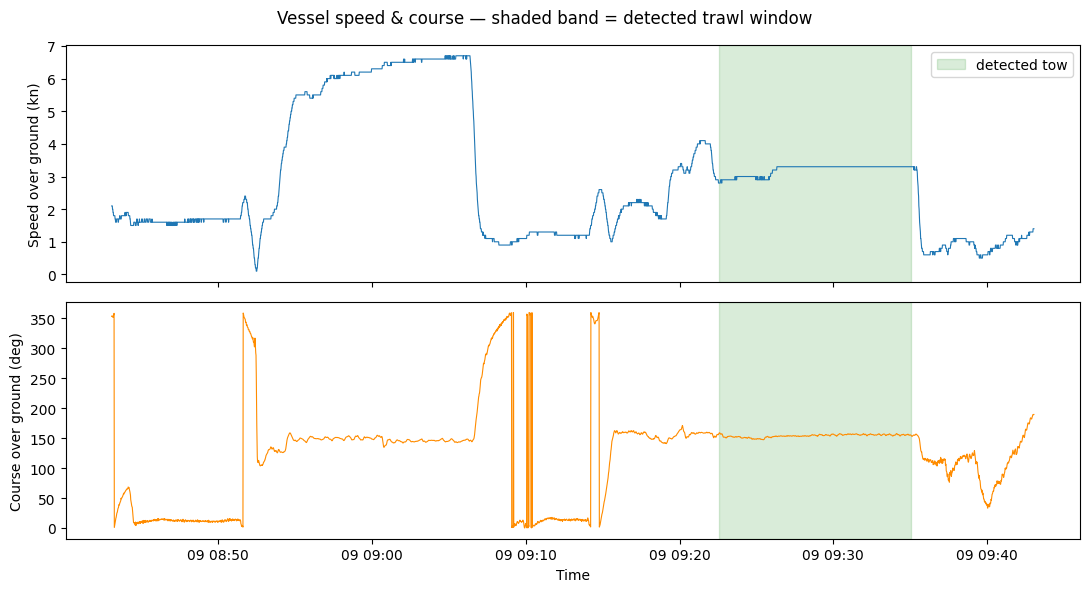

In [43]:

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(g["time"], g["sog_kn"], lw=0.8)
axes[0].set_ylabel("Speed over ground (kn)")
axes[0].axvspan(tow_start, tow_end, color="green", alpha=0.15, label="detected tow")
axes[0].legend(loc="upper right")

axes[1].plot(g["time"], g["cog_deg"], lw=0.8, color="darkorange")
axes[1].set_ylabel("Course over ground (deg)")
axes[1].axvspan(tow_start, tow_end, color="green", alpha=0.15)
axes[1].set_xlabel("Time")

fig.suptitle("Vessel speed & course — shaded band = detected trawl window")
fig.tight_layout()
plt.show()


## 4. Vessel speed at the requested time

In [44]:

query_dt = pd.Timestamp(g["time"].iloc[0].date().isoformat() + " " + QUERY_TIME)
idx = (g["time"] - query_dt).abs().idxmin()
row = g.loc[idx]

# nearest water-depth reading, for context
ddx = (dpt["time"] - query_dt).abs().idxmin() if len(dpt) else None

print(f"At {QUERY_TIME} (nearest logged sample {row['time']}):")
print(f"  Speed over ground : {row['sog_kn']:.1f} kn")
print(f"  Course over ground: {row['cog_deg']:.1f} deg")
if ddx is not None:
    print(f"  Water depth       : {dpt.loc[ddx, 'depth_m']:.1f} m")


At 09:23:00 (nearest logged sample 2026-06-09 09:23:00):
  Speed over ground : 2.9 kn
  Course over ground: 150.9 deg
  Water depth       : 19.1 m


## 5. Net width & net height from the `$PSIMTV80` gear sensors

Each `$PSIMTV80` record reports one sensor reading, tagged with a `sensor_id` + status flag pair. We treat `sensor_id + status1` as a unique **channel**, then — restricted to the trawl window found above — compute the mean / std for every channel.

A real geometry sensor (door spread, headline height, etc.) should be **stable** while the gear is fishing on the bottom; the most stable, *largest* reading is taken as net width (door/wing spread), and the most stable, *smallest* non-trivial reading is taken as net height (headline height).

In [45]:

tow_tv80 = tv80[(tv80["time"] >= tow_start) & (tv80["time"] <= tow_end)].copy()
pd.set_option('display.max_columns', None)
tow_tv80["channel"] = tow_tv80["sensor_id"] + "_" + tow_tv80["status1"]



stats = (
    tow_tv80.groupby("sensor_id")["value"]
    .agg(["count", "mean", "std", "min", "max"])
                        # need enough samples to trust it
    .assign(rel_std=lambda d: d["std"] / d["mean"].abs())
    .sort_values("mean")
)

display(stats.round(2))


,count,mean,std,min,max,rel_std
sensor_id,,,,,,
04,163,0.34,8.07,-49.97,10.82,23.81
02,59,1.46,0.20,1.32,2.27,0.14
19,61,6.88,0.25,6.71,7.82,0.04
16,1,10.90,NaN,10.90,10.90,NaN
05,162,14.12,4.45,4.81,21.81,0.32
03,59,20.54,0.51,19.30,21.58,0.02
01,75,55.29,2.65,41.67,58.48,0.05
06,218,64.99,18.13,47.56,94.36,0.28
17,119,110.72,0.86,109.88,114.28,0.01


In [46]:

candidates = stats[(stats["rel_std"] < STABLE_REL_STD) & (stats["mean"].abs() > MIN_SIGNAL_M)]

width_channel  = candidates["mean"].idxmax()
height_channel = candidates["mean"].idxmin()

net_width  = stats.loc['01',  "mean"]
net_height = stats.loc['02', "mean"]

print(f"Net WIDTH  (channel 01) : {net_width:.2f} m "
      f"(range {stats.loc['01','min']:.1f}-{stats.loc['01','max']:.1f} m)")
print(f"Net HEIGHT (channel 02): {net_height:.2f} m "
      f"(range {stats.loc['02','min']:.1f}-{stats.loc['02','max']:.1f} m)")


Net WIDTH  (channel 01) : 55.29 m (range 41.7-58.5 m)
Net HEIGHT (channel 02): 1.46 m (range 1.3-2.3 m)


## 6. Summary

In [47]:

print("="*55)
print("TRAWL SUMMARY")
print("="*55)
print(f"Tow window      : {tow_start.time()} - {tow_end.time()}")
print(f"Tow duration     : {tow_duration.total_seconds()/60:.1f} minutes")
print(f"Speed @ {QUERY_TIME} : {row['sog_kn']:.1f} kn")
print(f"Net width        : ~{net_width:.2f} m")
print(f"Net height       : ~{net_height:.2f} m")
print("="*55)
print("Note: width/height channel identification is heuristic")
print("(see markdown notes above) - confirm against the boat's")
print("TV80 sensor configuration for full certainty.")


TRAWL SUMMARY
Tow window      : 09:22:33 - 09:35:04
Tow duration     : 12.5 minutes
Speed @ 09:23:00 : 2.9 kn
Net width        : ~55.29 m
Net height       : ~1.46 m
Note: width/height channel identification is heuristic
(see markdown notes above) - confirm against the boat's
TV80 sensor configuration for full certainty.


In [48]:
# CALCULATION FISH DENSITY DAY 1
volume = row['sog_kn']*30.8666666666*tow_duration.total_seconds()/60* net_width * net_height
print(f"Volume swept : {volume:.2f} m³")
density = 197/volume
print(f" Density: {density} kg/m³")
print(row['sog_kn'])
print(tow_duration.total_seconds()/60)
print(net_width)
print(net_height)

Volume swept : 90153.98 m³
 Density: 0.002185150263742209 kg/m³
2.9
12.516666666666667
55.29293333333334
1.4552542372881356


In [49]:
# CALCULATION FISH DENSITY DAY 3
volume = row['sog_kn']*30.8666666666*tow_duration.total_seconds()/60* net_width * net_height
print(f"Volume swept : {volume:.2f} m³")
density = 187/volume
print(f" Density: {density} kg/m³")

Volume swept : 90153.98 m³
 Density: 0.002074228930557325 kg/m³
